## Support Vector Machine(SVM)

### 알고리즘의 원리
- 클래스 간의 분리를 최대화하는 방향으로 결정 경계를 생성
- 선형적으로 구분 가능한 데이터를 분류할 때 사용.

![](https://velog.velcdn.com/images/newnew_daddy/post/cee82bb1-c3df-4a8c-a170-0ef77e86336d/image.png)

- **초평면(Hyperplane)**:
    - 클래스 간의 결정 경계.

- **마진(Margin)**:
  - 결정 경계와 데이터 포인트 간의 거리.
  - 마진이 클수록 모델의 일반화 성능이 향상된다.

- **서포트 벡터(Support Vectors)**:
    - 결정 경계를 형성하는 데 중요한 역할을 하는 데이터 포인트들
    - 서포트 벡터는 마진의 가장자리에 위치하며, 결정 경계의 위치를 정의하는 데 사용된다.

---
> 데이터를 **직선(또는 초평면)으로 나눌 수 있을 때**

활용하면 좋은 경우:
- 클래스가 **선형적으로 분리 가능**하거나 근사적으로 가능할 때
- **고차원 데이터** (텍스트 분류, TF-IDF 벡터 등)
- **데이터 양이 많을 때** — 계산이 빠름
- 특성(feature) 수가 샘플 수보다 많을 때

대표 예시:
- 스팸 메일 분류
- 감성 분석

In [1]:
# 나이·추정연봉으로 구매 여부(이진) 예측하는 예제 데이터
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import evaluate_cls_model, plot_cm

df = pd.read_csv('./dataset/svm.csv')

df.head(), df.shape

(   Age  EstimatedSalary  Purchased
 0   19            19000          0
 1   35            20000          0
 2   26            43000          0
 3   27            57000          0
 4   19            76000          0,
 (400, 3))

In [2]:
X = df[['Age', 'EstimatedSalary']]  # 특성: 연령, 추정 연봉
y = df['Purchased'].to_frame()      # 타깃: 구매(1) 여부

X.shape, y.shape

((400, 2), (400, 1))

In [3]:
# 학습/검증 분할 (SVM은 스케일에 민감하므로 다음 셀에서 표준화)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((280, 2), (120, 2), (280, 1), (120, 1))

In [4]:
# 선형 SVM: 마진·거리 개념이 있으므로 특성 스케일 맞춤이 중요
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
train_scaled = ss.fit_transform(X_train)
test_scaled = ss.transform(X_test)

#### SVC 메소드의 주요 인자 설명

```python
from sklearn.svm import SVC

model = SVC(
    C=1.0,                  # 규제 강도. C가 클수록 규제가 약해짐. 데이터 적합과 마진 최대화 사이의 균형.
    kernel='rbf',           # 커널 종류. ('linear', 'poly', 'rbf', 'sigmoid', 'precomputed')
    degree=3,               # 다항식 커널의 차수. kernel='poly'일 때만 사용.
    tol=0.001,              # 종료 기준. 최적화가 수렴하는 데 사용하는 허용 오차.
    class_weight=None,      # 클래스 가중치. {class_label: weight} 형식의 dict 또는 'balanced'. 불균형 데이터셋에서 유용.
    verbose=False,          # 상세 출력을 원할 경우 설정. 0은 출력하지 않음을 의미.
    max_iter=-1,            # 최대 반복 횟수. -1이면 무제한 반복.
    random_state=None       # 난수 시드 설정. 결과 재현성을 위해 사용.
)
```

In [5]:
from sklearn.svm import SVC
"""
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

- kernel : 주요 커널 함수 (‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’)
- C(정규화 파라미터) : SVM은 정규화 파라미터 C를 사용하여 마진 최대화와 오차 최소화 사이의 균형을 조절한다. 
                   C가 클수록 오차 허용을 줄이고, 작은 마진을 선택할 가능성이 높아진다. 
                   반면, C가 작을수록 오차를 더 허용하고, 큰 마진을 유지하려고 한다.
"""

# 선형 커널: 클래스를 직선(초평면)으로 나눌 수 있다고 가정할 때 적합
svc = SVC(kernel='linear', random_state=0)
svc.fit(train_scaled, y_train.values.ravel())

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


=== SVM (Linear) ===
Train Score: 0.8214
Test  Score: 0.8500

              precision    recall  f1-score   support

           0       0.81      0.99      0.89        73
           1       0.97      0.64      0.77        47

    accuracy                           0.85       120
   macro avg       0.89      0.81      0.83       120
weighted avg       0.87      0.85      0.84       120



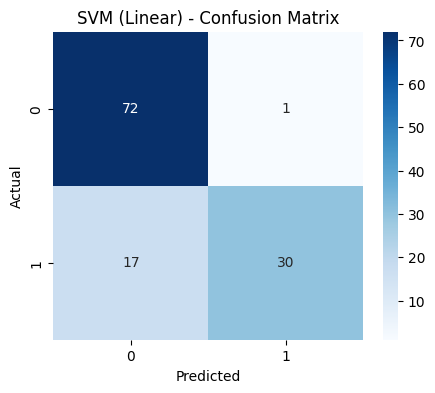

,test,pred
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
...,...,...
115,0,0
116,0,0
117,1,0
118,0,0


In [6]:
# 선형 SVM: 평가·시각화 (utils — Classification_Models.ipynb와 동일)
y_pred_linear = evaluate_cls_model(svc, train_scaled, test_scaled, y_train, y_test, "SVM (Linear)")
plot_cm(y_test, y_pred_linear, "SVM (Linear)")

yt = pd.DataFrame(y_test.values, columns=["test"])
yp = pd.DataFrame(y_pred_linear, columns=["pred"])
pd.concat([yt, yp], axis=1)


## 비선형 SVM (Kernel SVM)

![](https://velog.velcdn.com/images/newnew_daddy/post/89f3f96d-23a9-4689-a4ec-1f0072ecb8ff/image.png)

- 저차원에서 선형으로 분리되지 않을 때, 커널(RBF 등)으로 **고차원 매핑**을 간접 수행해 경계를 찾습니다.
- 아래는 **표준화하지 않은 원특성**으로 학습하는 예시(선형 SVM 셀과 설정 비교).


In [7]:
# RBF 커널 (선형 모델과 구분 위해 별도 변수명 사용)
from sklearn.svm import SVC

svc_rbf = SVC(kernel="rbf", random_state=0)
svc_rbf.fit(X_train, y_train.values.ravel())


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


=== SVM (RBF) ===
Train Score: 0.7786
Test  Score: 0.7417

              precision    recall  f1-score   support

           0       0.71      0.96      0.82        73
           1       0.86      0.40      0.55        47

    accuracy                           0.74       120
   macro avg       0.79      0.68      0.68       120
weighted avg       0.77      0.74      0.71       120



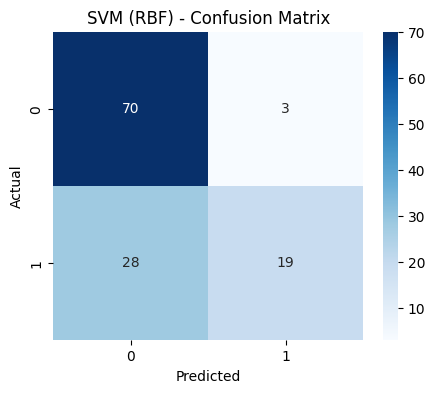

,test,pred
0,0,0
1,1,0
2,0,0
3,1,0
4,0,0
...,...,...
115,0,0
116,0,0
117,1,0
118,0,0


In [8]:
# RBF SVM: 평가·시각화 (utils)
y_pred_rbf = evaluate_cls_model(svc_rbf, X_train, X_test, y_train, y_test, "SVM (RBF)")
plot_cm(y_test, y_pred_rbf, "SVM (RBF)")

yt = pd.DataFrame(y_test.values, columns=["test"])
yp = pd.DataFrame(y_pred_rbf, columns=["pred"])
pd.concat([yt, yp], axis=1)
